In [1]:
import pandas as pd
import numpy as np
from pathlib import Path 

np.random.seed(42)
frequency = 64
path = Path(f"data/raw/dreamt/data_{frequency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_patients = 25
X_all_patients = []
y_all_patients = []
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_patients):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[~df["Sleep_Stage"].isin(["Missing","P"])]    
    y_all_patients.append(df.Sleep_Stage.to_numpy())
    X_all_patients.append(df.drop(columns=["Sleep_Stage"]).to_numpy())

In [2]:
WINDOWS_SEC = 30
FS = 64

window_samples = FS * WINDOWS_SEC

X_acc_patients = []
y_patients = []

for patient in range(len(X_all_patients)):
    X_bvp = []
    X_acc = []
    X_eda_temp = []
    X_hr = []
    y = []
    data = X_all_patients[patient]
    T = data.shape[0]
    n_windows = T // window_samples
    for i in range(n_windows):
        start = i * window_samples
        end = start + window_samples
        # 960
        X_acc.append(data[start:end:2, 1:4])
        y.append(y_all_patients[patient][start])
    
    X_acc_patients.append(np.stack(X_acc))
    y_patients.append(np.array(y))
        


In [3]:
X_acc_train = []
X_acc_test = []

y_train = []
y_test = []

test_size = 0.2

test_patients = np.random.choice(nb_patients, size= int(test_size * nb_patients))

for patient in range(nb_patients):
    if patient not in test_patients:
        X_acc_train.append(X_acc_patients[patient])
        y_train.append(y_patients[patient])

    else:
        X_acc_test.append(X_acc_patients[patient])
        y_test.append(y_patients[patient])


X_acc_train =np.concatenate(X_acc_train)
X_acc_test =np.concatenate(X_acc_test)
y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)


X_acc_train = np.permute_dims(X_acc_train, axes=[0,2,1])
X_acc_test      = np.permute_dims(X_acc_test, axes=[0,2,1])


In [4]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

In [5]:
import torch
import torch.nn as nn


class CNN(nn.Module):
    def __init__(self, channel_in=3, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv1d(
            in_channels=channel_in,
            out_channels=128,
            kernel_size=kernel_size,
            stride=1,
            padding="same",
        )
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)
        self.bn4 = nn.BatchNorm1d(32)

        self.maxpool = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(
            in_channels=128,
            out_channels=64,
            kernel_size=kernel_size,
            stride=1,
            padding="same",
        )

        self.conv3 = nn.Conv1d(
            in_channels=64,
            out_channels=32,
            kernel_size=kernel_size,
            stride=1,
            padding="same",
        )

        self.conv4 = nn.Conv1d(
            in_channels=32,
            out_channels=32,
            kernel_size=kernel_size,
            stride=1,
            padding="same",
        )

        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, 5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = x.mean(dim=2)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


In [6]:
from torch.utils.data import Dataset, DataLoader
class DreamtDataset(Dataset):
    def __init__(self, X_acc, y):
        super().__init__()
        self.X_acc      = X_acc
        self.y          = y

    def __getitem__(self, index):
        return (
            self.X_acc[index],
            self.y[index],
        )

    def __len__(self):
        return len(self.X_acc)


X_acc_train      = torch.FloatTensor(X_acc_train)
y_train_encoded  = torch.LongTensor(y_train_encoded)  

train_ds = DreamtDataset(X_acc_train, y_train_encoded)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

In [7]:
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train_encoded.numpy())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded.numpy())
weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")

In [10]:
from tqdm import tqdm



X_acc_test       = torch.FloatTensor(X_acc_test)
y_test_encoded   = torch.LongTensor(y_test_encoded)

test_ds = DreamtDataset(X_acc_test, y_test_encoded)
test_dl = DataLoader(test_ds, batch_size=1024)


def train_model(model, train_dl, epochs, weights= None, lr=0.001, device=torch.device("cpu")):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    if weights is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    else: 
        criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for x_acc, y in train_dl:
            x_acc = x_acc.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x_acc)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl.dataset)
        print("Train loss: %.3f" % (empirical_risk))
        
def test_model(model, test_dl, device=torch.device("cpu")):
    criterion = nn.CrossEntropyLoss(reduction="sum")
    model.eval()
    generalization_error = 0.0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_acc, y in test_dl:
            x_acc = x_acc.to(device)
            y = y.to(device)
            logits = model(x_acc)
            loss = criterion(logits, y)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            generalization_error += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()
        generalization_error /= len(test_dl.dataset)
        accuracy = correct / len(test_dl.dataset)
        print(
            "Generalization Error: %.3f, Accuracy %.3f"
            % (generalization_error, accuracy)
        )

    return y_true, y_pred


model = CNN(channel_in=3)
model.to(DEVICE)

train_model(model, train_dl, weights=weights, epochs=30,device = DEVICE)


  3%|▎         | 1/30 [00:13<06:31, 13.52s/it]

Train loss: 1.502


  7%|▋         | 2/30 [00:27<06:18, 13.52s/it]

Train loss: 1.439


 10%|█         | 3/30 [00:40<06:05, 13.52s/it]

...

Train loss: 1.133


 97%|█████████▋| 29/30 [06:32<00:13, 13.51s/it]

Train loss: 1.123


100%|██████████| 30/30 [06:45<00:00, 13.52s/it]

Train loss: 1.132


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = test_model(model, test_dl, DEVICE)

print(classification_report(y_true, y_pred, target_names=lb.classes_))

Generalization Error: 1.809, Accuracy 0.184
              precision    recall  f1-score   support

          N1       0.06      0.29      0.10       293
          N2       0.43      0.09      0.14      2031
          N3       0.11      0.21      0.14       241
           R       0.04      0.05      0.04       552
           W       0.33      0.39      0.36      1156

    accuracy                           0.18      4273
   macro avg       0.19      0.20      0.16      4273
weighted avg       0.31      0.18      0.19      4273



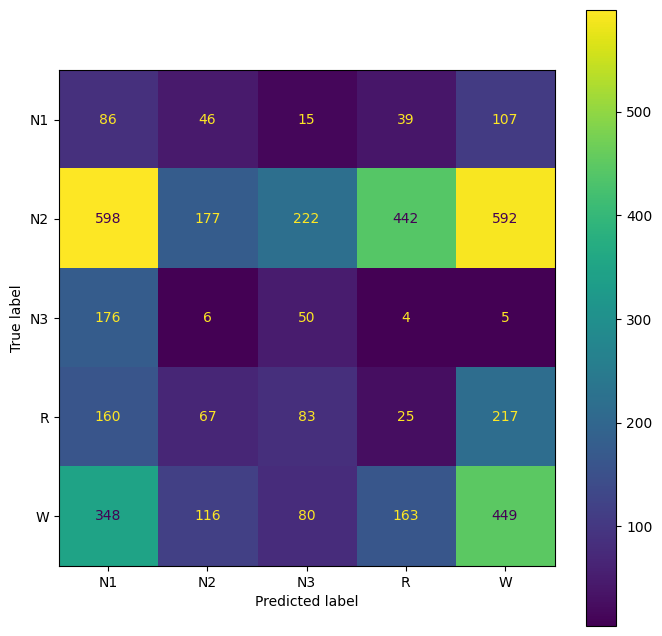

In [12]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=lb.classes_).plot(ax=ax)
fig.savefig(f"reports/figures/confusion_matrix_U=25_C=5_M=CNN.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)